In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys

sys.path.append("../../src")
from utils import write_extxyz
from structure import fcc_positions

In [2]:
def compute_forces(positions, epsilon=1.0, sigma=1.0e-1, box=None, cutoff=None):
    """
    Simple Lennard-Jones potential forces calculation.
    """
    forces = np.zeros_like(positions)  # No forces in this basic example
    num_particles = positions.shape[0]
    ndim = positions.shape[1]
    for i in range(num_particles):
        force = np.zeros(ndim)
        for j in range(num_particles):
            if i != j:
                r_ij = positions[j] - positions[i]
                for dim in range(ndim):
                    box_length = box[dim]
                    if r_ij[dim] > box_length / 2:
                        r_ij[dim] -= box_length
                    elif r_ij[dim] < -box_length / 2:
                        r_ij[dim] += box_length
                r = np.linalg.norm(r_ij)
                if cutoff is not None and r > cutoff:
                    continue
                if r > 0:
                    force += (
                        48 * epsilon * (sigma**12 / r**14)
                        - 24 * epsilon * (sigma**6 / r**8)
                    ) * r_ij
        forces[i] = force
    return forces


def compute_potential_energy(positions, epsilon=1.0, sigma=1.0e-1, box=None):
    """
    Simple Lennard-Jones potential energy calculation.
    """
    num_particles = positions.shape[0]
    energy = 0.0
    ndim = positions.shape[1]
    for i in range(num_particles):
        for j in range(i + 1, num_particles):
            r_ij = positions[j] - positions[i]
            for dim in range(ndim):
                box_length = box[dim]
                if r_ij[dim] > box_length / 2:
                    r_ij[dim] -= box_length
                elif r_ij[dim] < -box_length / 2:
                    r_ij[dim] += box_length
            r = np.linalg.norm(r_ij)
            if r > 0:
                energy += 4 * epsilon * ((sigma / r) ** 12 - (sigma / r) ** 6)
    return energy

In [3]:
total_time = 10.0  # total simulation time
num_steps = 1000  # number of time steps
dt = total_time / num_steps  # time step size

In [ ]:
n_cell = 10
box = (100.0,)  # simulation box dimensions
# epsilon = 1.0
# sigma = 50.0 / np.sqrt(2)
a = box[0] / n_cell
sigma = (a) / 2 ** (1 / 6)  # これで r_nn = r_min
epsilon = 1.0

initial_positions = np.arange(n_cell) * a
initial_positions = initial_positions.reshape(-1, 1)

In [ ]:
num_particles = initial_positions.shape[0]
initial_velocities = np.random.rand(num_particles, 1) * box * 0.0
masses = np.ones(num_particles)  # mass of each particle

random_delta = np.random.rand(num_particles, 1) * 0.01

initial_positions += random_delta

In [ ]:
ndim = initial_positions.shape[1]
positions_T = np.zeros((num_steps, initial_positions.shape[0], ndim))
positions_T[0] = initial_positions
velocities_T = np.zeros((num_steps, initial_velocities.shape[0], ndim))
velocities_T[0] = initial_velocities
velocities = initial_velocities.copy()
positions_T[1] = (
    initial_positions
    + velocities * dt
    + 0.5
    * compute_forces(
        initial_positions, epsilon=epsilon, sigma=sigma, box=box, cutoff=0.1
    )
    / masses[:, np.newaxis]
    * dt**2
) % box  # Apply periodic boundary conditions
for t in range(2, num_steps):
    next_positions = (
        2 * positions_T[t - 1]
        - positions_T[t - 2]
        + (
            compute_forces(
                positions_T[t - 1], epsilon=epsilon, sigma=sigma, box=box, cutoff=10
            )
            / masses[:, np.newaxis]
            * dt**2
        )
    )
    next_positions %= box  # Apply periodic boundary conditions
    positions_T[t] = next_positions
    velocities_T[t] = (positions_T[t] - positions_T[t - 1]) / dt  # Approximate velocity

In [25]:
positions_T.shape

(1000, 10, 1)

In [26]:
print(positions_T)

[[[3.75361092e-03]
  [1.00025875e+01]
  [2.00068711e+01]
  ...
  [7.00008654e+01]
  [8.00018220e+01]
  [9.00062216e+01]]

 [[3.75361092e-03]
  [1.00025875e+01]
  [2.00068711e+01]
  ...
  [7.00008654e+01]
  [8.00018220e+01]
  [9.00062216e+01]]

 [[3.75351683e-03]
  [1.00025874e+01]
  [2.00068714e+01]
  ...
  [7.00008653e+01]
  [8.00018220e+01]
  [9.00062218e+01]]

 ...

 [[3.19023438e+01]
  [2.67409977e+01]
  [1.45264294e+01]
  ...
  [6.53593750e+01]
  [2.05262248e+01]
  [1.71402299e+01]]

 [[5.45187966e+01]
  [7.36556784e+01]
  [2.86220899e+01]
  ...
  [2.15943172e+01]
  [3.80808166e+01]
  [9.05466683e+01]]

 [[5.90860898e+01]
  [2.05703591e+01]
  [4.27074740e+01]
  ...
  [7.78396060e+01]
  [5.56353382e+01]
  [2.16149401e+01]]]


Text(0, 0.5, 'Position')

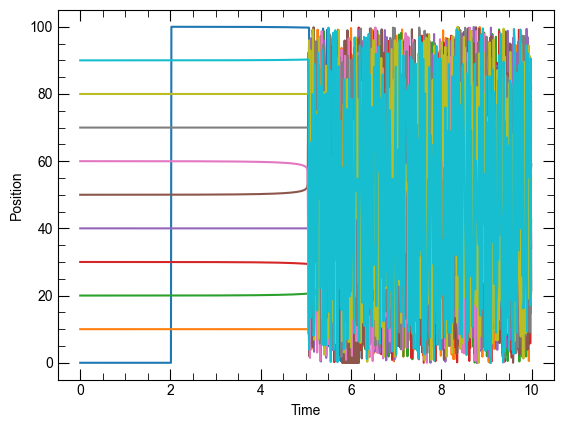

In [ ]:
fig, ax = plt.subplots()
for i in range(num_particles):
    ax.plot(np.arange(num_steps) * dt, positions_T[:, i, 0], label=f"Particle {i}")
ax.set_xlabel("Time")
ax.set_ylabel("Position")

In [10]:
poteintial_energies = []
kinetic_energies = []
total_energies = []
for t in range(num_steps):
    pe = compute_potential_energy(positions_T[t], epsilon=epsilon, sigma=sigma, box=box)
    ke = 0.5 * np.sum(
        masses[:, np.newaxis] * velocities_T[t] ** 2
    )  # Kinetic energy: 1/2 m v^2
    poteintial_energies.append(pe)
    kinetic_energies.append(ke)
    total_energies.append(pe + ke)

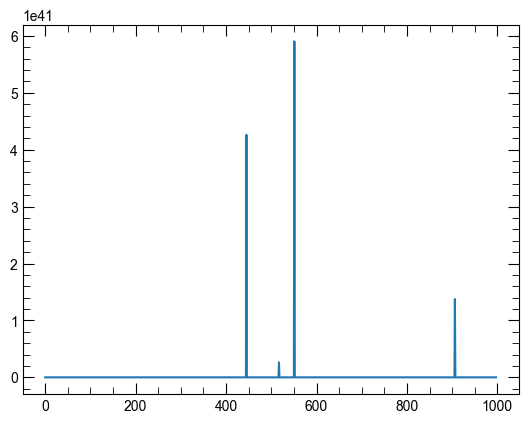

In [11]:
fig, ax = plt.subplots()
ax.plot(poteintial_energies[2:], label="Potential Energy")
# ax.plot(kinetic_energies, label="Kinetic Energy")
# ax.plot(total_energies, label="Total Energy")

In [ ]:
import numpy as np


def lj_force_scalar(r, epsilon, sigma):
    # F(r) = 24*eps/r * [2*(sig/r)^12 - (sig/r)^6]
    sr6 = (sigma / r) ** 6
    return 24 * epsilon * (2 * sr6 * sr6 - sr6) / r


def lj_potential(r, epsilon, sigma):
    sr6 = (sigma / r) ** 6
    return 4 * epsilon * (sr6 * sr6 - sr6)


def compute_forces_shifted(positions, epsilon, sigma, box, rc):
    n, d = positions.shape
    forces = np.zeros_like(positions)
    # 事前に rc での力と単位ベクトルにかかるスカラーを用意
    frc = lj_force_scalar(rc, epsilon, sigma)  # スカラー
    for i in range(n):
        fi = np.zeros(d)
        for j in range(n):
            if i == j:
                continue
            rij = positions[j] - positions[i]
            # PBC: 最小イメージ
            for k in range(d):
                L = box[k]
                if rij[k] > 0.5 * L:
                    rij[k] -= L
                elif rij[k] < -0.5 * L:
                    rij[k] += L
            r = np.linalg.norm(rij)
            if r >= rc or r == 0.0:
                continue
            rhat = rij / r
            f = lj_force_scalar(r, epsilon, sigma) - frc  # shifted-force
            fi += f * rhat
        forces[i] = fi
    return forces


def potential_energy_shifted(positions, epsilon, sigma, box, rc):
    n, d = positions.shape
    U = 0.0
    Urc = lj_potential(rc, epsilon, sigma)
    Frc = lj_force_scalar(rc, epsilon, sigma)
    for i in range(n):
        for j in range(i + 1, n):
            rij = positions[j] - positions[i]
            for k in range(d):
                L = box[k]
                if rij[k] > 0.5 * L:
                    rij[k] -= L
                elif rij[k] < -0.5 * L:
                    rij[k] += L
            r = np.linalg.norm(rij)
            if r >= rc or r == 0.0:
                continue
            # U_SF(r) = U_LJ(r) - U_LJ(rc) - (r-rc) * F_LJ(rc)
            U += lj_potential(r, epsilon, sigma) - Urc - (r - rc) * Frc
    return U


# ---- パラメータ ----
total_time = 10.0
num_steps = 10000  # dtを小さく
dt = total_time / num_steps

n_cell = 4
box = (100.0,)
# a = box[0] / n_cell
a = 5.0
sigma = a ** (1 / 6)  # 最近接 = r_min
epsilon = 1.0
# rc = 2.5 * sigma
# 例: rc を L/2 より小さく
L = box[0]
# rc = min(2.5 * sigma, 0.30 * L)  # <= L/2 を強制
rc = 2.5 * sigma
print(f"rc = {rc}")

# さらに念のため dt を小さく
dt = min(dt, 0.005)


# 初期配置 & 微小変位
x0 = (np.arange(n_cell) * a).reshape(-1, 1)
x0 += (np.random.rand(n_cell, 1) - 0.5) * (0.1 * a)
x0 += 40
print(x0)

rc = 3.2691512150295763
[[39.81419213]
 [44.83073795]
 [50.19446502]
 [55.22905594]]


In [ ]:
box

(100.0,)

In [ ]:
# 初期速度（ドリフト除去）
v0 = np.zeros_like(x0)
v0 -= v0.mean(axis=0)

m = np.ones(n_cell)

# ---- Velocity-Verlet ----
pos = np.zeros((num_steps, n_cell, 1))
pos[0] = x0
vel = np.zeros((num_steps, n_cell, 1))
vel[0] = v0

a0 = compute_forces_shifted(pos[0], epsilon, sigma, box, rc) / m[:, None]

# 1 step 目
pos[1] = (pos[0] + vel[0] * dt + 0.5 * a0 * dt * dt) % box
a1 = compute_forces_shifted(pos[1], epsilon, sigma, box, rc) / m[:, None]
vel[1] = vel[0] + 0.5 * (a0 + a1) * dt

for t in range(1, num_steps - 1):
    pos[t + 1] = (pos[t] + vel[t] * dt + 0.5 * a1 * dt * dt) % box
    a2 = compute_forces_shifted(pos[t + 1], epsilon, sigma, box, rc) / m[:, None]
    vel[t + 1] = vel[t] + 0.5 * (a1 + a2) * dt
    a1 = a2  # 次へ

In [ ]:
pos

array([[[39.81419213],
        [44.83073795],
        [50.19446502],
        [55.22905594]],

       [[39.81419213],
        [44.83073795],
        [50.19446502],
        [55.22905594]],

       [[39.81419213],
        [44.83073795],
        [50.19446502],
        [55.22905594]],

       ...,

       [[39.81419213],
        [44.83073795],
        [50.19446502],
        [55.22905594]],

       [[39.81419213],
        [44.83073795],
        [50.19446502],
        [55.22905594]],

       [[39.81419213],
        [44.83073795],
        [50.19446502],
        [55.22905594]]], shape=(10000, 4, 1))

(49.5, 50.5)

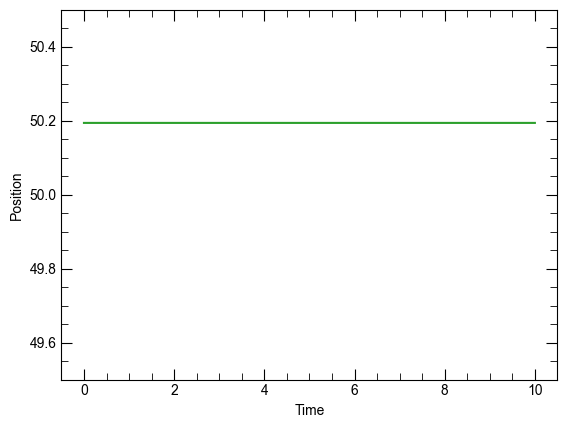

In [ ]:
fig, ax = plt.subplots()
num_particles = pos.shape[1]
for i in range(num_particles):
    ax.plot(np.arange(num_steps) * dt, pos[:, i, 0], label=f"Particle {i}")
ax.set_xlabel("Time")
ax.set_ylabel("Position")
delta = 0.1 * a
ax.set_ylim(50 - delta, 50 + delta)

In [ ]:
pos[:, 0, 0]

array([-4.49936273e-03,  9.99955006e+01,  9.99955006e+01, ...,
        6.40000000e+01,  6.40000000e+01,  6.40000000e+01], shape=(100000,))

(99.0, 100.0)

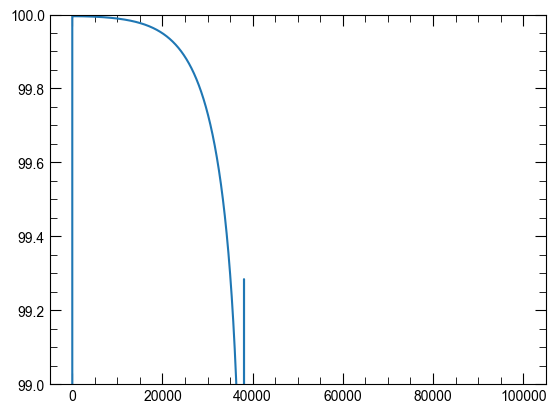

In [ ]:
fig, ax = plt.subplots()
ax.plot(pos[:, 0, 0])
ax.set_ylim(99, 100)

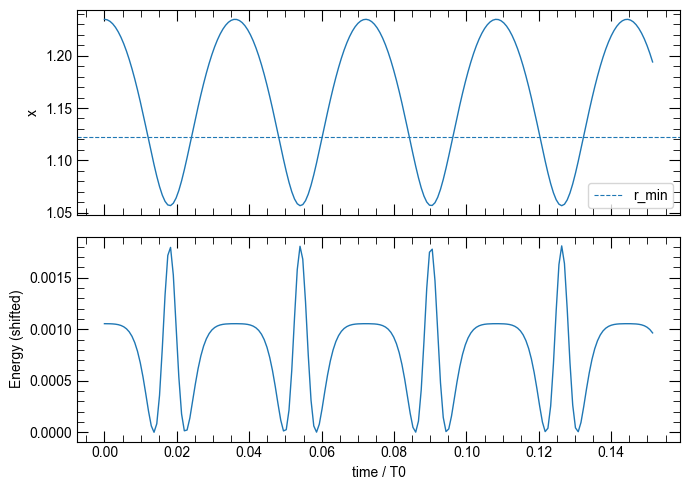

Linearized omega0 ≈ 0.2391, T0 ≈ 26.2836


In [82]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 物理パラメータ ----
epsilon = 1.0
sigma = 1.0
m = 1.0  # 動く粒子の質量
rmin = 2 ** (1 / 6) * sigma

# 小振動の理論角振動数（LJをrminで2次まで展開）
# k = d2U/dr2 |_{rmin} = 72*epsilon/rmin^2

# ---- 初期条件（固定粒子は原点、動く粒子をrminから微小変位）----
x_fixed = 0.0
x = rmin * (1 + 1e-1)  # 微小変位
v = 0.0

# ---- 時間離散（安定のため dt << 1/omega0）----
dt = 0.02  # かなり保守的
n_periods = 200
total_time = n_periods * dt
nsteps = int(total_time / dt)


# ---- 力とポテンシャル（1次元、固定点との相互作用のみ）----
def lj_force_1d(x, x0, epsilon, sigma):
    r = abs(x - x0)
    if r == 0.0:
        return 0.0
    sr6 = (sigma / r) ** 6
    # F = -dU/dr * r_hat  → 1Dでは符号は位置差の符号で与える
    f_scalar = 24 * epsilon * (2 * sr6 * sr6 - sr6) / r
    return f_scalar * np.sign(x - x0)


def lj_potential_1d(x, x0, epsilon, sigma):
    r = abs(x - x0)
    sr6 = (sigma / r) ** 6
    return 4 * epsilon * (sr6 * sr6 - sr6)


# ---- 記録用配列 ----
xt = np.empty(nsteps)
vt = np.empty(nsteps)
Et = np.empty(nsteps)
tt = np.arange(nsteps) * dt
xt[0] = x
vt[0] = v
Et[0] = 0.5 * m * v**2 + lj_potential_1d(x, x_fixed, epsilon, sigma)

# ---- Velocity-Verlet ----
a = lj_force_1d(x, x_fixed, epsilon, sigma) / m
# 1ステップ目
x = x + v * dt + 0.5 * a * dt * dt
a_new = lj_force_1d(x, x_fixed, epsilon, sigma) / m
v = v + 0.5 * (a + a_new) * dt

xt[1] = x
vt[1] = v
Et[1] = 0.5 * m * v**2 + lj_potential_1d(x, x_fixed, epsilon, sigma)
a = a_new

for t in range(2, nsteps):
    x = x + v * dt + 0.5 * a * dt * dt
    a_new = lj_force_1d(x, x_fixed, epsilon, sigma) / m
    v = v + 0.5 * (a + a_new) * dt
    a = a_new

    xt[t] = x
    vt[t] = v
    Et[t] = 0.5 * m * v**2 + lj_potential_1d(x, x_fixed, epsilon, sigma)

# ---- 可視化 ----
fig, ax = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
ax[0].plot(tt / T0, xt, lw=1)
ax[0].axhline(rmin, ls="--", lw=0.8, label="r_min")
ax[0].set_ylabel("x")
ax[0].legend()

ax[1].plot(tt / T0, Et - Et.min(), lw=1)  # オフセットして見やすく
ax[1].set_xlabel("time / T0")
ax[1].set_ylabel("Energy (shifted)")
plt.tight_layout()
plt.show()

# 参考：数値から周期をざっくり推定
# 最大/最小を拾って周期を確認したい場合は、np.where(np.diff(np.sign(vt))<0) 等で極値時刻を抽出
print(f"Linearized omega0 ≈ {omega0:.4f}, T0 ≈ {T0:.4f}")

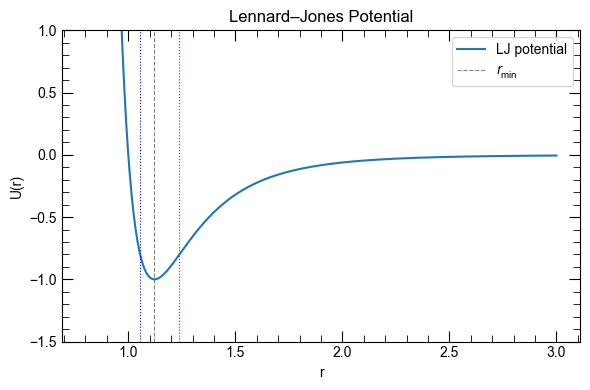

In [ ]:
# ---- LJポテンシャルをプロット ----
r = np.linspace(0.8 * sigma, 3 * sigma, 500)
U = [lj_potential_1d(x, 0.0, epsilon, sigma) for x in r]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(r, U, label="LJ potential")
ax.axvline(rmin, color="gray", ls="--", lw=0.8, label=r"$r_{\mathrm{min}}$")
ax.set_xlabel("r")
ax.set_ylabel("U(r)")
ax.set_title("Lennard–Jones Potential")
ax.legend()
ax.set_ylim(-1.5 * epsilon, 1.0 * epsilon)
ax.axvline(xt.max(), color="red", ls=":", lw=0.8, label="Max displacement")
ax.axvline(xt.min(), color="blue", ls=":", lw=0.8, label="Min displacement")
plt.tight_layout()
plt.show()